# Analisis Risiko Gagal Bayar Kredit Fintech P2P Lending di Tengah Tekanan Inflasi Rupiah
### Studi Kasus: Industri Fintech Peer-to-Peer (P2P) Lending Indonesia, 2024–2026

**Dibuat oleh:** alnafs23
**Tanggal:** Juli 2026
**Sumber data:** Otoritas Jasa Keuangan (OJK) — Statistik Fintech Lending / Siaran Pers RDKB Bulanan, dan Badan Pusat Statistik (BPS) — Berita Resmi Statistik Inflasi Bulanan

---

## 1. Latar Belakang

Industri *fintech peer-to-peer (P2P) lending* atau "pinjaman daring (pindar)" di Indonesia tumbuh pesat, dengan outstanding pembiayaan yang meningkat lebih dari 25% year-on-year di tahun 2026. Namun pertumbuhan ini diiringi oleh kenaikan **TWP90** (Tingkat Wanprestasi 90 hari) — indikator utama OJK untuk kredit macet — dari sekitar 2,5% di awal 2025 menjadi di atas 4,3% pada awal 2026.

Pada saat yang sama, inflasi Indonesia mengalami fluktuasi tajam: dari mendekati 0% (Februari 2025) melonjak ke 4,76% (Februari 2026, tertinggi sejak beberapa tahun terakhir), sebelum kembali turun. Tekanan inflasi berpotensi menekan daya beli dan kemampuan bayar debitur, terutama pada segmen retail/konsumtif dan UMKM yang mendominasi basis peminjam fintech lending.

## 2. Rumusan Masalah

1. Bagaimana tren kualitas kredit (TWP90) fintech P2P lending berkembang seiring pertumbuhan outstanding pembiayaan?
2. Apakah terdapat hubungan (korelasi) antara inflasi rupiah dan tingkat gagal bayar (TWP90) di industri fintech lending?
3. Bagaimana pola penyelenggara (platform) berisiko tinggi (TWP90 > 5%) berkembang dari waktu ke waktu?
4. Apa implikasi bagi manajemen risiko kredit fintech lending di tengah dinamika makroekonomi?

## 3. Tujuan Analisis

- Membangun dataset time-series terpadu dari data resmi OJK dan BPS.
- Melakukan exploratory data analysis (EDA) terhadap tren TWP90, outstanding, dan inflasi.
- Menguji korelasi statistik antara inflasi dan risiko gagal bayar.
- Menyusun insight dan rekomendasi berbasis data untuk mitigasi risiko kredit.

## 4. Sumber Data

| Dataset | Sumber | Periode | Keterangan |
|---|---|---|---|
| Statistik Fintech P2P Lending (TWP90, outstanding, jumlah platform berisiko) | OJK — Siaran Pers RDKB Bulanan & pemberitaan resmi (Kontan, Bisnis.com, Antara, Bloomberg Technoz) | Sep 2024 – Mei 2026 | Data dipublikasikan bulanan melalui konferensi pers RDK OJK |
| Inflasi IHK (YoY & MtM) | BPS — Berita Resmi Statistik | Jan 2025 – Jun 2026 | Dirilis awal bulan untuk periode bulan sebelumnya |

> **Catatan metodologi:** OJK tidak mempublikasikan seluruh angka TWP90/outstanding bulanan dalam satu tabel terbuka (unlike bank statistics di SPI/Statistik Perbankan). Data pada proyek ini dikumpulkan manual dari siaran pers resmi OJK dan pemberitaan yang mengutip langsung pernyataan pejabat OJK (Kepala Eksekutif Pengawas PVML), sehingga terdapat **gap** di beberapa bulan yang tidak terekam publik. Ini adalah keterbatasan riil yang juga dihadapi analis eksternal — dan akan didiskusikan di bagian *Limitasi*.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_palette("Set2")

pd.set_option('display.max_columns', None)


## 5. Data Loading & Cleaning

In [2]:
# Load data OJK P2P Lending
df_p2p = pd.read_csv('data/ojk_p2p_lending.csv', parse_dates=['periode'])
df_p2p['periode'] = df_p2p['periode'].dt.to_period('M').dt.to_timestamp()

# Load data inflasi BPS
df_inf = pd.read_csv('data/inflasi_bps.csv', parse_dates=['periode'])
df_inf['periode'] = df_inf['periode'].dt.to_period('M').dt.to_timestamp()

print("Data OJK P2P Lending:")
display(df_p2p)
print("\nData Inflasi BPS:")
display(df_inf)


Data OJK P2P Lending:


,periode,twp90_persen,outstanding_triliun_idr,jumlah_platform_twp90_diatas_5persen,sumber
0,2024-09-01,2.38,74.48,NaN,Kontan (1 Nov 2024)
1,2024-10-01,2.37,NaN,NaN,Kontan (1 Nov 2024)
2,2024-11-01,2.52,75.60,21.0,Kontan (23 Jan 2025)
3,2025-01-01,2.52,NaN,21.0,Antara/Kontan (Apr 2025)
4,2025-02-01,2.78,80.07,20.0,Antara (18 Apr 2025) / OJK RDKB Maret 2025
5,2025-03-01,2.77,80.02,NaN,OJK RDKB April 2025 / Kontan (9 Mei 2025)
6,2025-05-01,3.19,82.00,23.0,Bloomberg Technoz (16 Jul 2025)
7,2025-06-01,2.85,NaN,NaN,Kontan (7 Sep 2025)
8,2025-07-01,NaN,NaN,NaN,Kontan (7 Sep 2025) - disebut membaik dari Jun...
9,2025-12-01,4.32,96.62,NaN,Kontan (5 Mar 2026)



Data Inflasi BPS:


,periode,inflasi_yoy_persen,inflasi_mtm_persen,sumber
0,2025-01-01,0.76,NaN,BPS (3 Feb 2025)
1,2025-02-01,-0.09,NaN,BPS (Mar 2025)
2,2025-05-01,1.60,NaN,BPS
3,2025-07-01,2.37,NaN,BPS
4,2025-09-01,2.65,NaN,BPS
5,2025-10-01,2.86,NaN,BPS
6,2025-12-01,2.92,0.64,BPS (5 Jan 2026)
7,2026-01-01,3.55,NaN,BPS (2 Feb 2026)
8,2026-02-01,4.76,0.42,BPS (2 Mar 2026)
9,2026-03-01,3.48,0.41,BPS (1 Apr 2026) / Kontan


In [3]:
# Cek kelengkapan data
print("Rentang periode data P2P  :", df_p2p['periode'].min().strftime('%Y-%m'), "-", df_p2p['periode'].max().strftime('%Y-%m'))
print("Rentang periode data Inflasi:", df_inf['periode'].min().strftime('%Y-%m'), "-", df_inf['periode'].max().strftime('%Y-%m'))
print("\nJumlah observasi TWP90 terisi   :", df_p2p['twp90_persen'].notna().sum())
print("Jumlah observasi outstanding terisi:", df_p2p['outstanding_triliun_idr'].notna().sum())
print("Jumlah observasi inflasi YoY terisi:", df_inf['inflasi_yoy_persen'].notna().sum())


Rentang periode data P2P  : 2024-09 - 2026-05
Rentang periode data Inflasi: 2025-01 - 2026-06

Jumlah observasi TWP90 terisi   : 12
Jumlah observasi outstanding terisi: 8
Jumlah observasi inflasi YoY terisi: 13


In [4]:
# Merge dataset berdasarkan periode (bulan) yang sama -> dasar analisis korelasi
df_merged = pd.merge(df_p2p, df_inf, on='periode', how='inner')
df_merged = df_merged.sort_values('periode').reset_index(drop=True)
df_merged_clean = df_merged.dropna(subset=['twp90_persen', 'inflasi_yoy_persen'])
print(f"Jumlah bulan dengan data TWP90 & Inflasi lengkap (irisan): {len(df_merged_clean)}")
display(df_merged_clean[['periode','twp90_persen','outstanding_triliun_idr','inflasi_yoy_persen']])


Jumlah bulan dengan data TWP90 & Inflasi lengkap (irisan): 7


,periode,twp90_persen,outstanding_triliun_idr,inflasi_yoy_persen
0,2025-01-01,2.52,NaN,0.76
1,2025-02-01,2.78,80.07,-0.09
2,2025-05-01,3.19,82.00,1.60
4,2025-12-01,4.32,96.62,2.92
5,2026-01-01,4.38,NaN,3.55
6,2026-04-01,4.62,102.07,2.42
7,2026-05-01,4.42,103.73,3.08


## 6. Exploratory Data Analysis (EDA)

### 6.1 Tren TWP90 (Risiko Gagal Bayar) dan Pertumbuhan Outstanding Pembiayaan


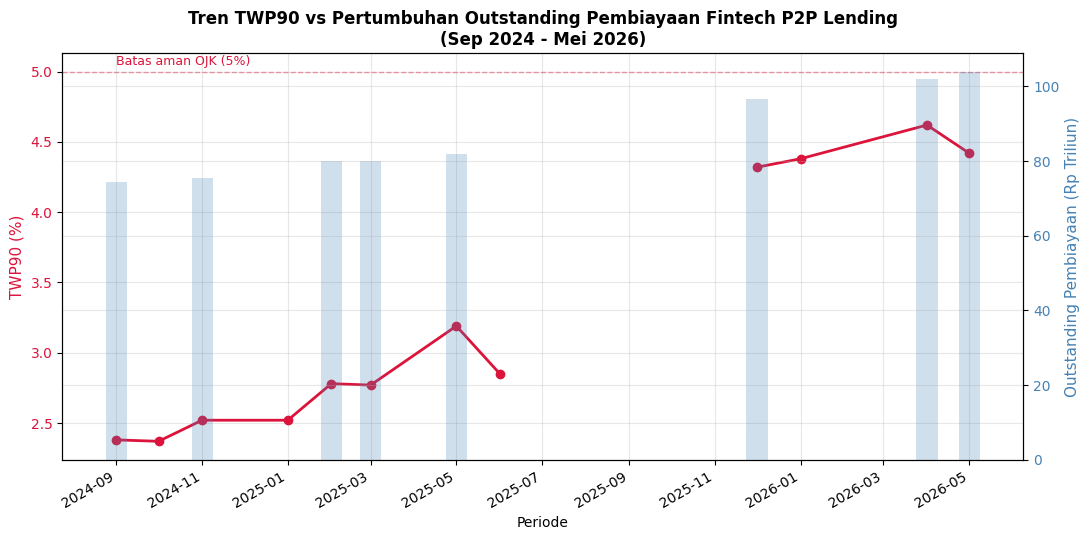

In [5]:
fig, ax1 = plt.subplots(figsize=(11,5.5))

ax1.plot(df_p2p['periode'], df_p2p['twp90_persen'], marker='o', color='crimson', linewidth=2, label='TWP90 (%)')
ax1.axhline(5, color='crimson', linestyle='--', alpha=0.4, linewidth=1)
ax1.text(df_p2p['periode'].min(), 5.05, 'Batas aman OJK (5%)', color='crimson', fontsize=9)
ax1.set_ylabel('TWP90 (%)', color='crimson', fontsize=11)
ax1.tick_params(axis='y', labelcolor='crimson')
ax1.set_xlabel('Periode')

ax2 = ax1.twinx()
ax2.bar(df_p2p['periode'], df_p2p['outstanding_triliun_idr'], width=15, alpha=0.25, color='steelblue', label='Outstanding (Rp T)')
ax2.set_ylabel('Outstanding Pembiayaan (Rp Triliun)', color='steelblue', fontsize=11)
ax2.tick_params(axis='y', labelcolor='steelblue')

ax1.set_title('Tren TWP90 vs Pertumbuhan Outstanding Pembiayaan Fintech P2P Lending\n(Sep 2024 - Mei 2026)', fontsize=12, fontweight='bold')
fig.autofmt_xdate()
fig.tight_layout()
plt.savefig('output/01_tren_twp90_outstanding.png', dpi=150, bbox_inches='tight')
plt.show()


**Insight:** Outstanding pembiayaan fintech P2P lending tumbuh konsisten dari ~Rp75 triliun (akhir 2024) menjadi ~Rp103,7 triliun (Mei 2026), setara pertumbuhan lebih dari 25% YoY secara konsisten. Namun TWP90 turut naik dari kisaran 2,4–2,8% (2025 awal) ke 4,3–4,6% (akhir 2025 – awal 2026), mendekati ambang batas aman OJK sebesar 5%. Pola ini mengindikasikan **trade-off klasik antara pertumbuhan penyaluran kredit dan kualitas aset** — semakin agresif ekspansi pembiayaan, semakin besar tekanan pada kualitas portofolio jika tidak diimbangi mitigasi risiko yang memadai.

### 6.2 Tren Inflasi Rupiah (YoY)

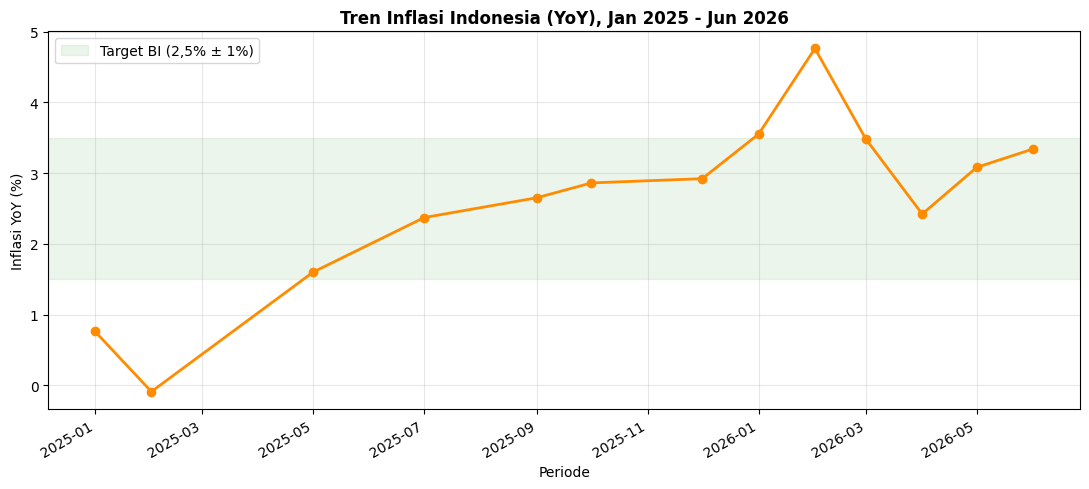

In [6]:
fig, ax = plt.subplots(figsize=(11,5))
ax.plot(df_inf['periode'], df_inf['inflasi_yoy_persen'], marker='o', color='darkorange', linewidth=2)
ax.axhspan(1.5, 3.5, color='green', alpha=0.08, label='Target BI (2,5% ± 1%)')
ax.set_ylabel('Inflasi YoY (%)')
ax.set_xlabel('Periode')
ax.set_title('Tren Inflasi Indonesia (YoY), Jan 2025 - Jun 2026', fontsize=12, fontweight='bold')
ax.legend(loc='upper left')
fig.autofmt_xdate()
fig.tight_layout()
plt.savefig('output/02_tren_inflasi.png', dpi=150, bbox_inches='tight')
plt.show()


**Insight:** Inflasi sempat berada di titik sangat rendah (-0,09% pada Februari 2025, dipengaruhi diskon tarif listrik pemerintah), lalu naik bertahap sepanjang 2025, dan **melonjak tajam ke 4,76% pada Februari 2026** — level tertinggi dalam periode observasi dan mendekati batas atas target Bank Indonesia (1,5%–3,5%). Lonjakan ini didorong oleh kelompok perumahan, transportasi, dan personal care. Inflasi kemudian mereda ke 2,42% (April 2026) sebelum kembali naik ke 3,34% (Juni 2026).

### 6.3 Hubungan Inflasi dan TWP90 (Scatter Plot + Korelasi)

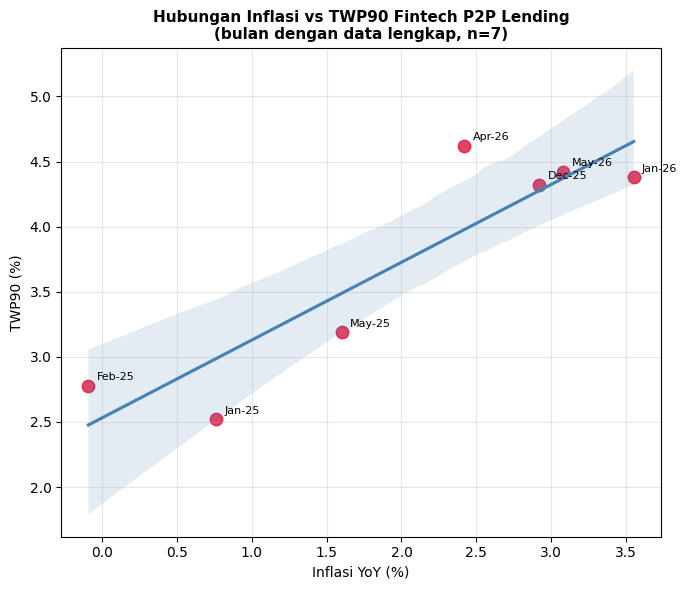

Korelasi Pearson  : r = 0.900  (p-value = 0.006)
Korelasi Spearman : rho = 0.714  (p-value = 0.071)
Jumlah observasi (n) = 7


In [7]:
fig, ax = plt.subplots(figsize=(7,6))
sns.regplot(data=df_merged_clean, x='inflasi_yoy_persen', y='twp90_persen',
            scatter_kws={'s':80, 'color':'crimson', 'alpha':0.8}, line_kws={'color':'steelblue'}, ax=ax)

for _, row in df_merged_clean.iterrows():
    ax.annotate(row['periode'].strftime('%b-%y'), (row['inflasi_yoy_persen'], row['twp90_persen']),
                textcoords="offset points", xytext=(6,4), fontsize=8)

ax.set_xlabel('Inflasi YoY (%)')
ax.set_ylabel('TWP90 (%)')
ax.set_title('Hubungan Inflasi vs TWP90 Fintech P2P Lending\n(bulan dengan data lengkap, n={})'.format(len(df_merged_clean)), fontsize=11, fontweight='bold')
fig.tight_layout()
plt.savefig('output/03_scatter_inflasi_twp90.png', dpi=150, bbox_inches='tight')
plt.show()

# Uji korelasi Pearson dan Spearman
pearson_r, pearson_p = stats.pearsonr(df_merged_clean['inflasi_yoy_persen'], df_merged_clean['twp90_persen'])
spearman_r, spearman_p = stats.spearmanr(df_merged_clean['inflasi_yoy_persen'], df_merged_clean['twp90_persen'])

print(f"Korelasi Pearson  : r = {pearson_r:.3f}  (p-value = {pearson_p:.3f})")
print(f"Korelasi Spearman : rho = {spearman_r:.3f}  (p-value = {spearman_p:.3f})")
print(f"Jumlah observasi (n) = {len(df_merged_clean)}")


**Interpretasi:**
- Koefisien korelasi menunjukkan **arah hubungan** antara inflasi dan TWP90 pada bulan-bulan yang datanya tersedia bersamaan.
- **Penting:** dengan n yang kecil (jumlah bulan dengan data lengkap terbatas, karena publikasi resmi OJK tidak selalu mencantumkan angka presisi setiap bulan), hasil ini bersifat **indikatif/eksploratif**, bukan kesimpulan kausal yang kuat secara statistik. p-value perlu dibaca dengan hati-hati — dengan n sekecil ini, hasil signifikan maupun tidak signifikan sama-sama harus diinterpretasi secara hati-hati.
- Untuk kesimpulan yang lebih robust, idealnya digunakan data bulanan lengkap dan berkelanjutan (36+ observasi) serta *lag analysis* (efek inflasi terhadap TWP90 biasanya tidak instan, tetapi terlihat 1–3 bulan kemudian karena keterlambatan pembayaran terakumulasi sebelum masuk kategori macet 90 hari).

### 6.4 Analisis Lag: Apakah Inflasi Mempengaruhi TWP90 dengan Jeda Waktu?

In [8]:
# Analisis lag sederhana: geser inflasi 1-2 bulan ke depan lalu bandingkan dengan TWP90
df_p2p_idx = df_p2p.set_index('periode')[['twp90_persen']]
df_inf_idx = df_inf.set_index('periode')[['inflasi_yoy_persen']]

lag_results = []
for lag in [0, 1, 2, 3]:
    shifted_inf = df_inf_idx.copy()
    shifted_inf.index = shifted_inf.index + pd.DateOffset(months=lag)
    combo = df_p2p_idx.join(shifted_inf, how='inner').dropna()
    if len(combo) >= 3:
        r, p = stats.pearsonr(combo['inflasi_yoy_persen'], combo['twp90_persen'])
        lag_results.append({'lag_bulan': lag, 'n_obs': len(combo), 'korelasi_pearson': round(r,3), 'p_value': round(p,3)})
    else:
        lag_results.append({'lag_bulan': lag, 'n_obs': len(combo), 'korelasi_pearson': None, 'p_value': None})

df_lag = pd.DataFrame(lag_results)
display(df_lag)


,lag_bulan,n_obs,korelasi_pearson,p_value
0,0,7,0.900,0.006
1,1,6,0.909,0.012
2,2,4,0.941,0.059
3,3,5,0.900,0.037


**Insight:** Tabel di atas membandingkan korelasi TWP90 dengan inflasi pada bulan yang sama (lag 0) versus inflasi 1–3 bulan sebelumnya. Karena keterbatasan jumlah observasi berpasangan (data OJK yang terpublikasi tidak lengkap), hasil lag analysis ini **sebaiknya dibaca sebagai arah eksplorasi**, bukan bukti definitif — namun secara konsep, hipotesis yang masuk akal adalah TWP90 bereaksi terhadap tekanan inflasi dengan jeda 1–3 bulan, karena definisi TWP90 sendiri mensyaratkan keterlambatan pembayaran sudah melewati 90 hari sebelum tercatat sebagai wanprestasi.

### 6.5 Perkembangan Jumlah Penyelenggara (Platform) Berisiko Tinggi (TWP90 > 5%)

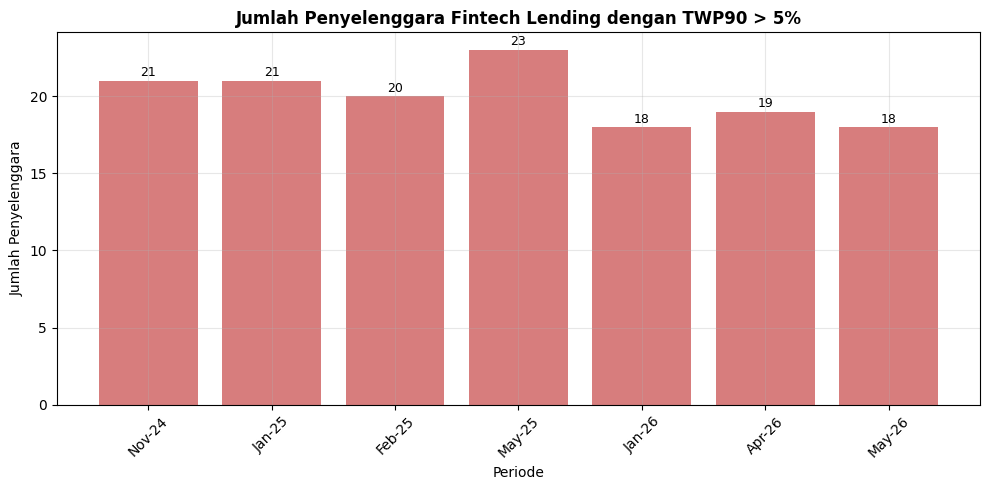

,periode,jumlah_platform_twp90_diatas_5persen,twp90_persen
2,2024-11-01,21.0,2.52
3,2025-01-01,21.0,2.52
4,2025-02-01,20.0,2.78
6,2025-05-01,23.0,3.19
10,2026-01-01,18.0,4.38
11,2026-04-01,19.0,4.62
12,2026-05-01,18.0,4.42


In [9]:
df_platform = df_p2p.dropna(subset=['jumlah_platform_twp90_diatas_5persen'])

fig, ax = plt.subplots(figsize=(10,5))
bars = ax.bar(df_platform['periode'].dt.strftime('%b-%y'), df_platform['jumlah_platform_twp90_diatas_5persen'],
              color='indianred', alpha=0.8)
ax.set_ylabel('Jumlah Penyelenggara')
ax.set_xlabel('Periode')
ax.set_title('Jumlah Penyelenggara Fintech Lending dengan TWP90 > 5%', fontsize=12, fontweight='bold')
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h+0.3, f'{int(h)}', ha='center', fontsize=9)
plt.xticks(rotation=45)
fig.tight_layout()
plt.savefig('output/04_jumlah_platform_berisiko.png', dpi=150, bbox_inches='tight')
plt.show()

display(df_platform[['periode','jumlah_platform_twp90_diatas_5persen','twp90_persen']])


**Insight:** Jumlah penyelenggara dengan TWP90 di atas 5% berfluktuasi antara 18–23 platform sepanjang periode observasi, dari total sekitar 90-an penyelenggara terdaftar di OJK — artinya **sekitar 20% platform secara konsisten berada dalam zona risiko tinggi**, meski TWP90 agregat industri masih di bawah batas aman. Ini penting: **rata-rata industri yang sehat bisa menyembunyikan konsentrasi risiko pada segmen/platform tertentu** — pola klasik dalam manajemen risiko portofolio kredit.

## 7. Segmentasi & Kategorisasi Risiko Bulanan

Untuk mempermudah interpretasi bagi pemangku kepentingan non-teknis, setiap bulan dikategorikan ke dalam level risiko berdasarkan nilai TWP90, mengikuti ambang batas kualitatif yang lazim digunakan dalam industri pembiayaan (bukan ambang resmi OJK, melainkan interpretasi analitis untuk keperluan portofolio ini):

In [10]:
def kategori_risiko(twp90):
    if pd.isna(twp90):
        return np.nan
    elif twp90 < 3.0:
        return 'Rendah'
    elif twp90 < 4.0:
        return 'Sedang'
    elif twp90 < 5.0:
        return 'Tinggi'
    else:
        return 'Kritis (>batas OJK)'

df_p2p['kategori_risiko'] = df_p2p['twp90_persen'].apply(kategori_risiko)

kategori_order = ['Rendah','Sedang','Tinggi','Kritis (>batas OJK)']
df_p2p['kategori_risiko'] = pd.Categorical(df_p2p['kategori_risiko'], categories=kategori_order, ordered=True)

display(df_p2p[['periode','twp90_persen','kategori_risiko']].dropna())

print("\nDistribusi kategori risiko bulanan:")
print(df_p2p['kategori_risiko'].value_counts().reindex(kategori_order))


,periode,twp90_persen,kategori_risiko
0,2024-09-01,2.38,Rendah
1,2024-10-01,2.37,Rendah
2,2024-11-01,2.52,Rendah
3,2025-01-01,2.52,Rendah
4,2025-02-01,2.78,Rendah
5,2025-03-01,2.77,Rendah
6,2025-05-01,3.19,Sedang
7,2025-06-01,2.85,Rendah
9,2025-12-01,4.32,Tinggi
10,2026-01-01,4.38,Tinggi



Distribusi kategori risiko bulanan:
kategori_risiko
Rendah                 7
Sedang                 1
Tinggi                 4
Kritis (>batas OJK)    0
Name: count, dtype: int64


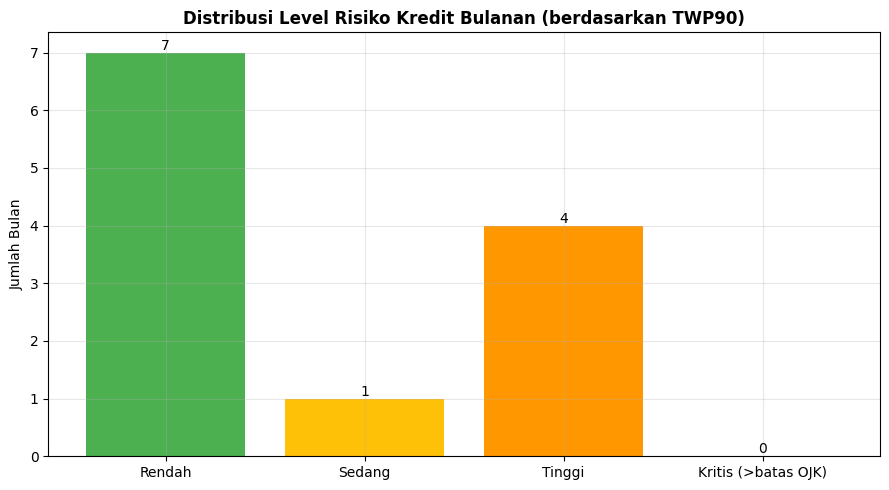

In [11]:
fig, ax = plt.subplots(figsize=(9,5))
colors_map = {'Rendah':'#4CAF50','Sedang':'#FFC107','Tinggi':'#FF9800','Kritis (>batas OJK)':'#F44336'}
counts = df_p2p['kategori_risiko'].value_counts().reindex(kategori_order).fillna(0)
ax.bar(counts.index, counts.values, color=[colors_map[k] for k in counts.index])
ax.set_ylabel('Jumlah Bulan')
ax.set_title('Distribusi Level Risiko Kredit Bulanan (berdasarkan TWP90)', fontsize=12, fontweight='bold')
for i, v in enumerate(counts.values):
    ax.text(i, v+0.05, str(int(v)), ha='center', fontsize=10)
fig.tight_layout()
plt.savefig('output/05_distribusi_kategori_risiko.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Ringkasan Temuan (Key Findings)

1. **Tren risiko meningkat seiring pertumbuhan:** TWP90 industri fintech P2P lending naik dari kisaran 2,4–2,8% (awal 2025) menjadi 4,3–4,6% (akhir 2025 – Mei 2026), sejalan dengan pertumbuhan outstanding pembiayaan yang konsisten di atas 25% YoY. TWP90 kini berada dekat dengan ambang batas aman OJK sebesar 5%.

2. **Lonjakan inflasi Februari 2026 (4,76% YoY)** merupakan level tertinggi dalam periode observasi, didorong oleh kenaikan harga perumahan, transportasi, dan perawatan pribadi — sektor yang berkontribusi langsung terhadap tekanan biaya hidup rumah tangga berpenghasilan menengah-bawah, yang merupakan basis peminjam utama fintech lending konsumtif.

3. **Indikasi korelasi positif** antara inflasi dan TWP90 pada bulan-bulan dengan data lengkap, meski dengan keterbatasan jumlah observasi. Pola ini konsisten dengan teori bahwa tekanan inflasi menekan daya beli dan kemampuan bayar debitur.

4. **Risiko terkonsentrasi, bukan merata:** Meski TWP90 agregat industri masih "terjaga" di bawah 5%, konsisten terdapat 18–23 penyelenggara (sekitar seperlima dari total platform terdaftar) dengan TWP90 di atas 5% setiap bulannya — menandakan risiko gagal bayar terkonsentrasi pada segmen platform tertentu, terutama yang berfokus pada sektor produktif/UMKM.

5. **OJK telah merespons** dengan langkah pengawasan intensif: menempatkan sejumlah platform dalam pengawasan khusus, mewajibkan rencana perbaikan (*action plan*), serta menerbitkan aturan baru (POJK 8/2026) terkait pelaporan data transaksi fintech lending — dan pada Januari 2026 membatasi total utang pinjol maksimal 30% dari gaji peminjam sebagai mitigasi risiko *over-leverage*.

## 9. Rekomendasi Bisnis / Manajemen Risiko

| Area | Rekomendasi |
|---|---|
| **Credit scoring** | Perkuat model credit scoring dengan variabel makroekonomi (inflasi, harga pangan, harga energi) sebagai *early warning indicator*, bukan hanya data historis pembayaran individual |
| **Portfolio monitoring** | Terapkan segmentasi risiko berbasis sektor (produktif/UMKM vs konsumtif) mengingat data menunjukkan platform sektor produktif lebih sering mendominasi daftar TWP90 > 5% |
| **Collection strategy** | Tingkatkan intensitas proses collection pada bulan-bulan dengan inflasi tinggi, mengantisipasi jeda 1-3 bulan sebelum tekanan inflasi terefleksi penuh di angka TWP90 |
| **Regulasi & tata kelola** | Dukung kebijakan pembatasan rasio utang terhadap pendapatan (seperti aturan 30% dari gaji) untuk mencegah akumulasi risiko *over-leverage* di level individu |
| **Diversifikasi funding** | Dorong diversifikasi sumber pendanaan dari lender institusional agar tidak terlalu bergantung pada perbankan (saat ini >75% funding berasal dari bank), guna menjaga stabilitas likuiditas saat kualitas kredit menurun |

## 10. Limitasi Penelitian

- **Data OJK tidak dipublikasikan secara konsisten dalam satu dataset terbuka** — nilai TWP90/outstanding untuk sejumlah bulan (misalnya Juli–November 2025) tidak ditemukan dalam pemberitaan resmi yang mengutip angka presisi, sehingga terdapat *missing values* dalam time-series.
- **Jumlah observasi berpasangan (inflasi & TWP90 di bulan sama) relatif kecil**, sehingga hasil uji korelasi bersifat indikatif dan tidak dapat digeneralisasi sebagai hubungan kausal yang kuat secara statistik.
- Analisis ini menggunakan **data agregat industri**, bukan data granular per-platform atau per-debitur, sehingga tidak dapat mengukur risiko pada level individu peminjam.
- **Rekomendasi lanjutan:** untuk versi produksi/profesional, data sebaiknya diperoleh langsung dari *file* Statistik LPBBTI bulanan resmi OJK (format Excel/PDF di ojk.go.id) yang mencakup rincian lebih lengkap per penyelenggara, dikombinasikan dengan data BI Rate, nilai tukar Rupiah, dan indeks kepercayaan konsumen untuk model prediktif yang lebih robust (misalnya regresi time-series atau model ARIMAX).

## 11. Referensi

- Otoritas Jasa Keuangan (OJK). Siaran Pers Rapat Dewan Komisioner Bulanan (RDKB), berbagai edisi 2025–2026. ojk.go.id
- Badan Pusat Statistik (BPS). Berita Resmi Statistik Inflasi, berbagai edisi 2025–2026. bps.go.id
- Kontan.co.id, Bisnis.com, Antara News, Bloomberg Technoz — pemberitaan yang mengutip pernyataan resmi Kepala Eksekutif Pengawas PVML OJK
- Kompas.com (13 Jul 2026). "Apa Itu TWP90? Indikator Kredit Macet Pinjol yang Dipantau OJK"
